In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


## LOAD DATA

In [2]:
# ==========================================
# 1. DATA PREPARATION
# ==========================================

# --- FOLDER CONFIGURATION ---
# Make sure this path matches your Drive folder structure
base_dir = 'DATASET_NEW'

# List of qualities based on your folder structure
qualities = ['Fresh', 'Spoiled']

data_list = []

# Loop to read files from the folder structure
for quality in qualities:
    folder_path = os.path.join(base_dir, quality)

    if os.path.exists(folder_path):
        files = os.listdir(folder_path)

        for file_name in files:
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.heic')):
                # Create label: "Fresh", "Spoiled", etc.
                label_name = f"{quality}"
                full_path = os.path.join(folder_path, file_name)
                data_list.append({'filepath': full_path, 'label': label_name})
    else:
        print(f"Warning: Folder not found -> {folder_path}")

# Convert to DataFrame
df = pd.DataFrame(data_list)
print(f"\nTotal data found: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")

# Check data distribution
print("\nNumber of samples per class:")
print(df['label'].value_counts())


Total data found: 1924
Number of classes: 2

Number of samples per class:
label
Fresh      1001
Spoiled     923
Name: count, dtype: int64


In [3]:
# Convert to DataFrame
df = pd.DataFrame(data_list)
print(f"\nInitial total data: {len(df)}")
print("Initial distribution:")
print(df['label'].value_counts())

# ==========================================
# 2. UNDERSAMPLING PROCESS
# ==========================================
print("\n--- Starting undersampling process ---")

# 1. Find the smallest sample count among all classes
min_sample = df['label'].value_counts().min()
print(f"Lowest sample count (undersampling target): {min_sample}")

# 2. Perform undersampling
# Group by label, then sample 'min_sample' from each group
df = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min_sample, random_state=42)
)

# Reset index for a clean DataFrame
df = df.reset_index(drop=True)

# 3. Check the balanced result
print(f"\nTotal data after undersampling: {len(df)}")
print("Distribution after undersampling:")
print(df['label'].value_counts())


Initial total data: 1924
Initial distribution:
label
Fresh      1001
Spoiled     923
Name: count, dtype: int64

--- Starting undersampling process ---
Lowest sample count (undersampling target): 923

Total data after undersampling: 1846
Distribution after undersampling:
label
Fresh      923
Spoiled    923
Name: count, dtype: int64


C:\Users\Azvadennys\AppData\Local\Temp\ipykernel_16832\4219606301.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label', group_keys=False).apply(


In [4]:
def visualize_split(train_df, val_df, test_df):
    # ==========================================
    # 1. PIE CHART: Overall Percentage
    # ==========================================
    sizes = [len(train_df), len(val_df), len(test_df)]
    labels = ['Training (70%)', 'Validation (20%)', 'Testing (10%)']
    colors = ['#4CAF50', '#FFC107', '#2196F3']  # Green, Yellow, Blue
    explode = (0.05, 0, 0)  # Slightly separate the Training slice

    plt.figure(figsize=(18, 6))

    # Subplot 1: Pie Chart
    plt.subplot(1, 2, 1)
    plt.pie(
        sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, pctdistance=0.85, explode=explode, shadow=True
    )

    # Create a center circle (Donut Chart) for a more aesthetic look
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title('Overall Data Split Proportion', fontsize=14, fontweight='bold')
    plt.axis('equal')

    # ==========================================
    # 2. STACKED BAR CHART: Distribution per Class
    # ==========================================
    # Count samples per class for each split
    train_counts = train_df['label'].value_counts().sort_index()
    val_counts = val_df['label'].value_counts().sort_index()
    test_counts = test_df['label'].value_counts().sort_index()

    # Combine counts into a single DataFrame for plotting
    df_counts = pd.DataFrame({
        'Training': train_counts,
        'Validation': val_counts,
        'Testing': test_counts
    })

    # Subplot 2: Stacked Bar Chart
    plt.subplot(1, 2, 2)

    # Plot
    df_counts.plot(kind='bar', stacked=True, color=colors, ax=plt.gca(), width=0.8)

    plt.title('Class-wise Data Distribution (Stratified)', fontsize=14, fontweight='bold')
    plt.xlabel('Class Label')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Dataset')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Show detailed table
    print("\nDetailed Sample Count per Class:")
    print(df_counts)


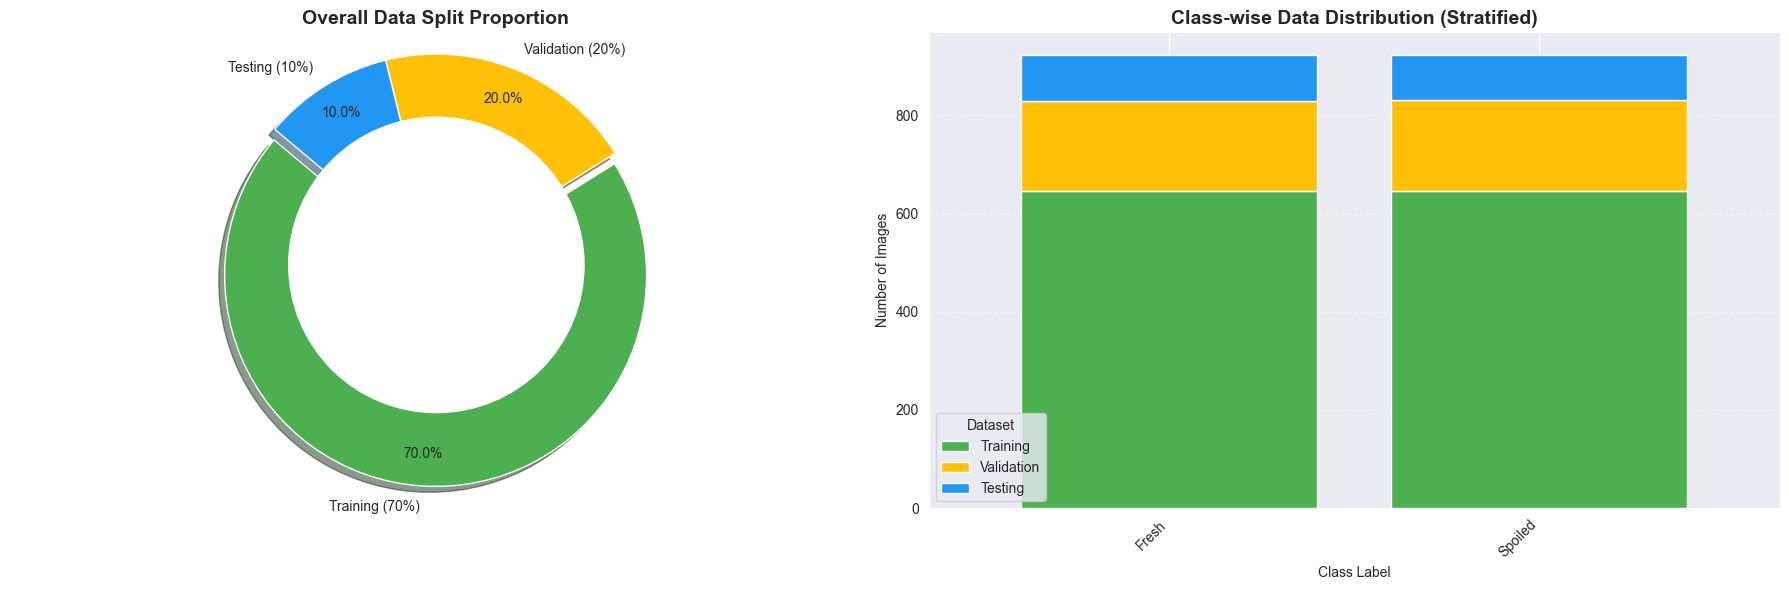


Detailed Sample Count per Class:
         Training  Validation  Testing
label                                 
Fresh         646         184       93
Spoiled       646         185       92

--- Data Split ---
Training   : 1292 (70.0%)
Validation : 369 (20.0%)
Test       : 185 (10.0%)


In [5]:
# ==========================================
# 2. DATA SPLITTING (70% Train, 20% Val, 10% Test)
# ==========================================
# Step 1: Split 70% for training
train_df, temp_df = train_test_split(
    df, train_size=0.7, stratify=df['label'], random_state=42
)

# Step 2: Split the remaining data (Temp) into validation and test
# Validation takes 2/3 of Temp (so it becomes 20% of the full dataset)
val_df, test_df = train_test_split(
    temp_df, train_size=2/3, stratify=temp_df['label'], random_state=42
)

visualize_split(train_df, val_df, test_df)

print(f"\n--- Data Split ---")
print(f"Training   : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation : {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test       : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

## AUGMENTASI

In [6]:
# ==========================================
# 3. DATA GENERATOR
# ==========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=60,
    width_shift_range=0.35,
    height_shift_range=0.35,
    shear_range=0.35,
    zoom_range=(0.7, 1.4),
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=(0.6, 1.4),
    channel_shift_range=30.0,
    fill_mode='nearest',  # often looks more natural than other fill modes
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

# Validation generator
val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Test generator (shuffle=False so prediction order matches the true labels for evaluation)
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(class_names)

Found 1292 validated image filenames belonging to 2 classes.
Found 369 validated image filenames belonging to 2 classes.
Found 185 validated image filenames belonging to 2 classes.
['Fresh', 'Spoiled']


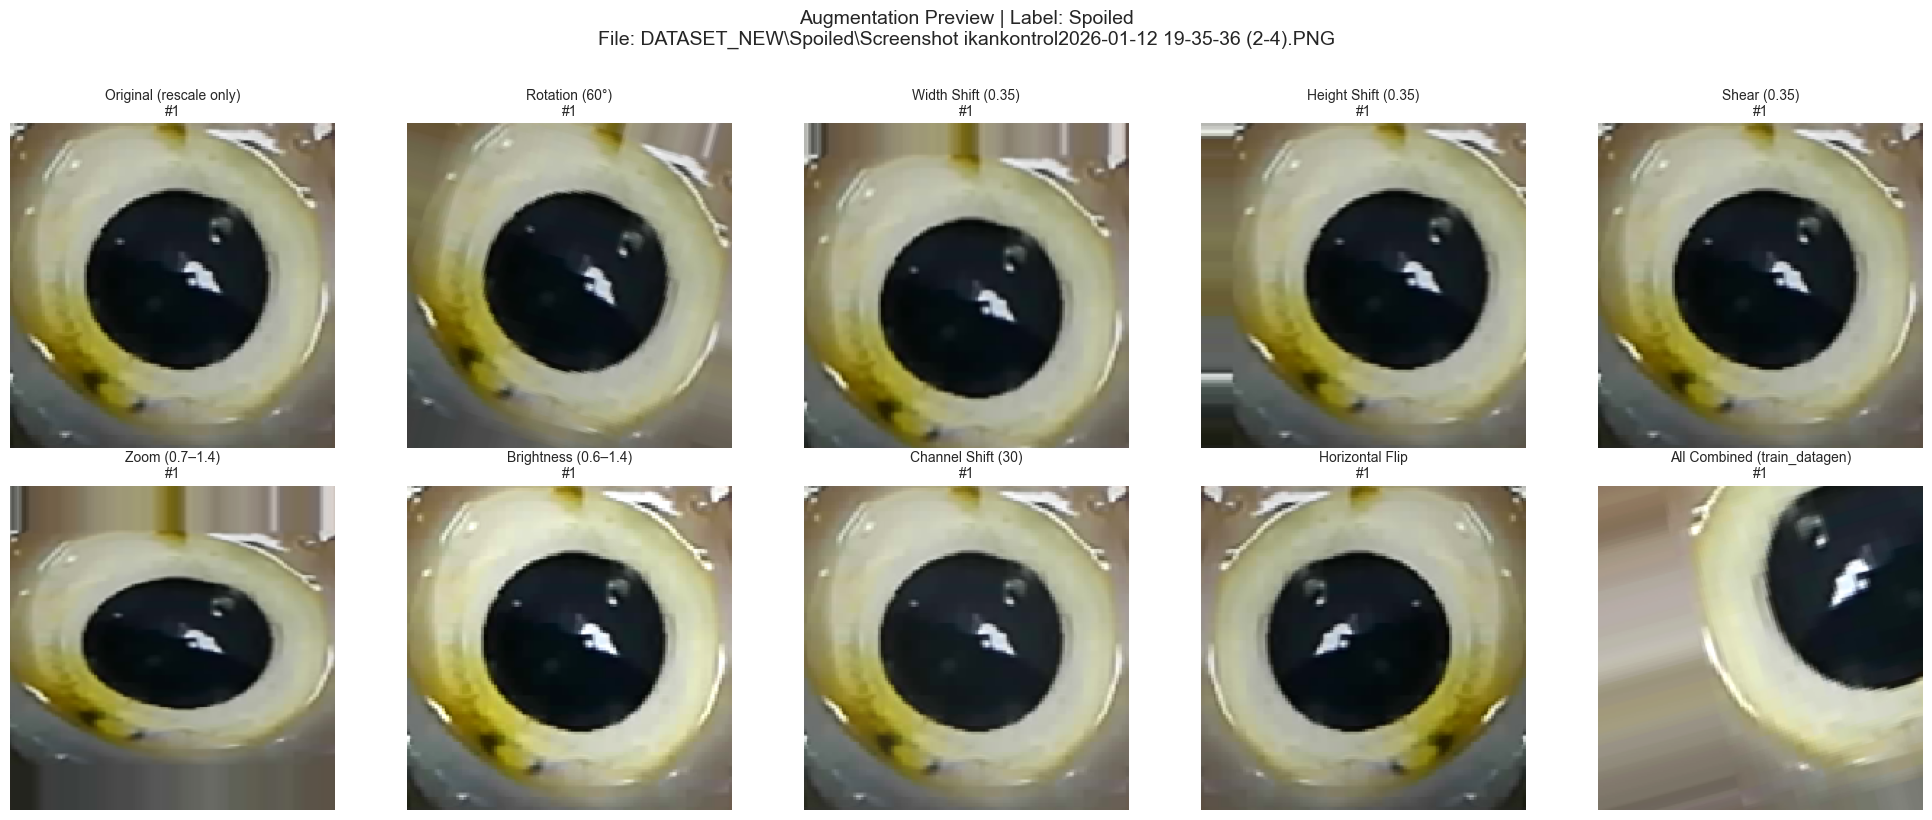

In [7]:
import numpy as np
import math
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

def _clip_for_display(img):
    # img is float, typically in [0,1], but augmentation can push outside
    return np.clip(img, 0.0, 1.0)

def visualize_specific_augmentations(
    dataframe,
    img_size=(150, 150),
    n_examples=1,
    seed=42
):
    # 1) Pick one sample
    sample_row = dataframe.sample(1, random_state=seed).iloc[0]
    img_path = sample_row["filepath"]
    label = sample_row["label"]

    # 2) Load image (no rescale yet)
    img = load_img(img_path, target_size=img_size)
    x = img_to_array(img)  # 0..255 float32
    x = x.reshape((1,) + x.shape)  # (1, H, W, 3)

    # 3) Define augmentations (match your current training settings)
    aug_types = {
        "Original (rescale only)": ImageDataGenerator(rescale=1./255),

        "Rotation (60°)": ImageDataGenerator(
            rescale=1./255, rotation_range=60, fill_mode="nearest"
        ),

        "Width Shift (0.35)": ImageDataGenerator(
            rescale=1./255, width_shift_range=0.35, fill_mode="nearest"
        ),

        "Height Shift (0.35)": ImageDataGenerator(
            rescale=1./255, height_shift_range=0.35, fill_mode="nearest"
        ),

        "Shear (0.35)": ImageDataGenerator(
            rescale=1./255, shear_range=0.35, fill_mode="nearest"
        ),

        "Zoom (0.7–1.4)": ImageDataGenerator(
            rescale=1./255, zoom_range=(0.7, 1.4), fill_mode="nearest"
        ),

        "Brightness (0.6–1.4)": ImageDataGenerator(
            rescale=1./255, brightness_range=(0.6, 1.4)
        ),

        "Channel Shift (30)": ImageDataGenerator(
            rescale=1./255, channel_shift_range=30.0
        ),

        "Horizontal Flip": ImageDataGenerator(
            rescale=1./255, horizontal_flip=True
        ),

        "All Combined (train_datagen)": ImageDataGenerator(
            rescale=1./255,
            rotation_range=60,
            width_shift_range=0.35,
            height_shift_range=0.35,
            shear_range=0.35,
            zoom_range=(0.7, 1.4),
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=(0.6, 1.4),
            channel_shift_range=30.0,
            fill_mode="nearest",
        ),
    }

    # 4) Plot layout (auto grid)
    n_plots = len(aug_types) * n_examples
    cols = 5
    rows = math.ceil(n_plots / cols)

    plt.figure(figsize=(cols * 4, rows * 4))
    plt.suptitle(f"Augmentation Preview | Label: {label}\nFile: {img_path}", fontsize=14, y=1.02)

    plot_idx = 1
    for name, datagen in aug_types.items():
        gen = datagen.flow(x, batch_size=1, seed=seed, shuffle=False)

        for k in range(n_examples):
            aug_img = next(gen)[0]  # (H,W,3) float
            aug_img = _clip_for_display(aug_img)

            plt.subplot(rows, cols, plot_idx)
            plt.imshow(aug_img)
            plt.title(f"{name}\n#{k+1}", fontsize=10)
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()

# Run
visualize_specific_augmentations(train_df, img_size=IMG_SIZE, n_examples=1, seed=42)

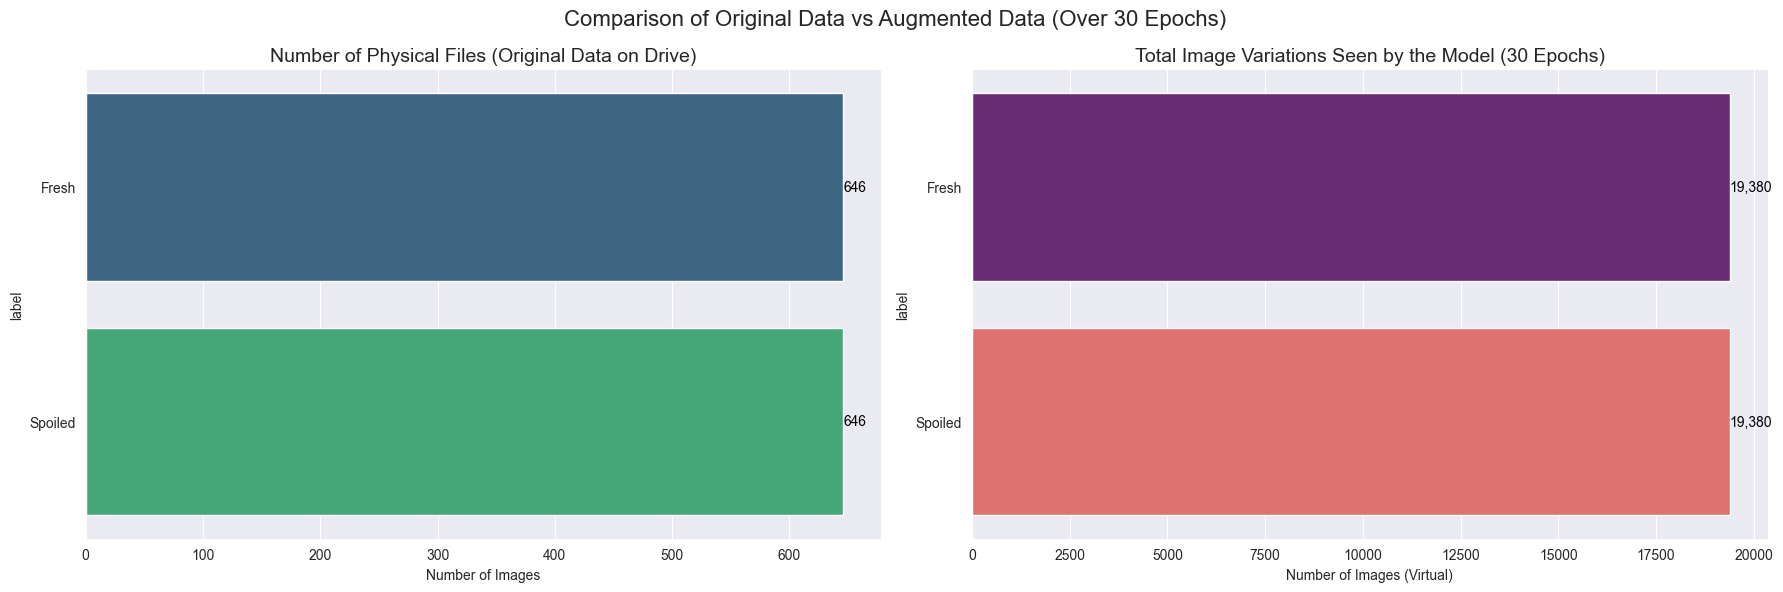


--- EXPLANATION ---
1. Total Original Training Files: 1292 images.
2. Since augmentation happens every epoch, over 30 epochs the model will learn from:
   1292 x 30 = 38760 different image variations.
3. This is why augmentation is very effective at preventing overfitting even when the original dataset is small.


In [8]:


def visualize_data_expansion(train_df, epochs=30):
    # Count original (physical) data
    original_counts = train_df['label'].value_counts()
    
    # Count virtual data (Original Data x Number of Epochs)
    virtual_counts = original_counts * epochs
    
    classes = original_counts.index
    
    # Plot setup
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot 1: Physical (Real) Data
    # FIX: Add hue=classes and legend=False
    sns.barplot(
        x=original_counts.values, y=classes,
        hue=classes, legend=False,
        ax=ax[0], palette='viridis'
    )
    
    ax[0].set_title('Number of Physical Files (Original Data on Drive)', fontsize=14)
    ax[0].set_xlabel('Number of Images')
    for i, v in enumerate(original_counts.values):
        ax[0].text(v + 0.2, i, str(v), color='black', va='center')

    # Plot 2: Virtual Data (Seen by the Model)
    # FIX: Add hue=classes and legend=False
    sns.barplot(
        x=virtual_counts.values, y=classes,
        hue=classes, legend=False,
        ax=ax[1], palette='magma'
    )
    
    ax[1].set_title(f'Total Image Variations Seen by the Model ({epochs} Epochs)', fontsize=14)
    ax[1].set_xlabel('Number of Images (Virtual)')
    for i, v in enumerate(virtual_counts.values):
        ax[1].text(v + 5, i, f"{v:,}", color='black', va='center')  # Thousands format

    plt.suptitle(
        f"Comparison of Original Data vs Augmented Data (Over {epochs} Epochs)",
        fontsize=16
    )
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- EXPLANATION ---")
    print(f"1. Total Original Training Files: {len(train_df)} images.")
    print(f"2. Since augmentation happens every epoch, over {epochs} epochs the model will learn from:")
    print(f"   {len(train_df)} x {epochs} = {len(train_df)*epochs} different image variations.")
    print("3. This is why augmentation is very effective at preventing overfitting even when the original dataset is small.")

# Run the visualization
visualize_data_expansion(train_df, epochs=30)


## TRAINING DATA

In [9]:
# ==========================================
# 4. Core Function (TRAIN, SAVE, EVALUATE)
# ==========================================
def run_experiment(model, exp_name, epochs=100):
    print(f"\n{'='*15} MULAI: {exp_name} {'='*15}")
    print("Training Device:", tf.test.gpu_device_name() if tf.test.is_gpu_available() else "CPU")
    # 1. Checkpoint: save best model (Best Weights) to file .keras
    checkpoint_path = f"{exp_name}_best_model.keras"
    checkpoint = callbacks.ModelCheckpoint(
        checkpoint_path, 
        monitor='val_loss', 
        save_best_only=True, 
        mode='min', 
        verbose=1
    )
    
    # 2. Early Stopping: stop if there is no improvement
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    
    # 3. Reduce LR: reduce learning rate if validation loss plateaus
    lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    
    # 4. CSV Logger
    csv_log = callbacks.CSVLogger(f'{exp_name}_training_log.csv')
    
    # --- TRAINING ---
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[checkpoint, early_stop, lr_schedule, csv_log],
        verbose=1
    )
    
    # Save the final version of the model (optional backup)
    model.save(f"{exp_name}_final_model.keras")
    print(f"Model saved successfully as: {checkpoint_path}")
    
    return history

def evaluate_and_plot(model, history, exp_name):
    # --- PLOT CURVES ---
    metrics_df = pd.DataFrame(history.history)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy curve
    sns.lineplot(data=metrics_df[['accuracy', 'val_accuracy']], ax=ax[0])
    ax[0].set_title(f'{exp_name}: Accuracy')
    
    # Loss curve
    sns.lineplot(data=metrics_df[['loss', 'val_loss']], ax=ax[1])
    ax[1].set_title(f'{exp_name}: Loss')
    plt.show()

    # --- TEST SET EVALUATION ---
    print(f"\n--- Evaluasi pada Data Test: {exp_name} ---")
    predictions = model.predict(test_gen)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_gen.classes

    # Classification Report
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predict')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.title(f'Confusion Matrix: {exp_name}')
    plt.show()
    
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)
num_classes = len(class_names)

In [10]:
from tensorflow.keras.applications import DenseNet121


=============== MULAI: Exp3_DenseNet121 ===============
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
Training Device: CPU


C:\Users\Azvadennys\Desktop\Training Edible Film\venv-39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.8080 - loss: 0.3747
Epoch 1: val_loss improved from inf to 0.74821, saving model to Exp3_DenseNet121_best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 22s 424ms/step - accuracy: 0.8098 - loss: 0.3717 - val_accuracy: 0.6911 - val_loss: 0.7482 - learning_rate: 0.0010
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9540 - loss: 0.1381
Epoch 2: val_loss improved from 0.74821 to 0.36920, saving model to Exp3_DenseNet121_best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 386ms/step - accuracy: 0.9540 - loss: 0.1380 - val_accuracy: 0.8455 - val_loss: 0.3692 - learning_rate: 0.0010
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9488 - loss: 0.1148
Epoch 3: val_loss improved from 0.36920 to 0.21038, saving model to Exp3_DenseNet121_best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 395ms/step - accuracy: 0.9488 - loss: 0.1154 - val_accuracy: 0.9214 - val_loss: 0.2104 - learning_rate: 0.0010
Epoch 4/200

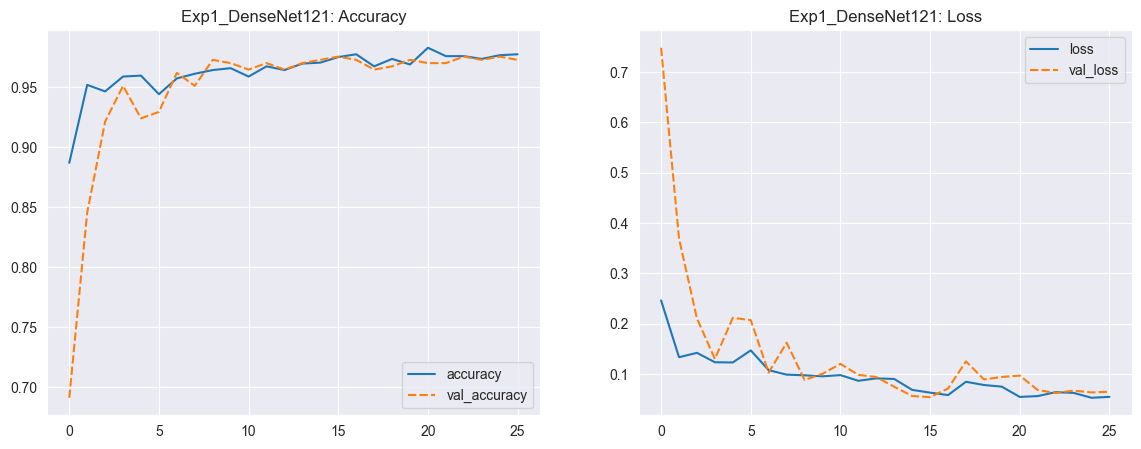


--- Evaluasi pada Data Test: Exp1_DenseNet121 ---


C:\Users\Azvadennys\Desktop\Training Edible Film\venv-39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 487ms/step
              precision    recall  f1-score   support

       Fresh       0.97      1.00      0.98        93
     Spoiled       1.00      0.97      0.98        92

    accuracy                           0.98       185
   macro avg       0.98      0.98      0.98       185
weighted avg       0.98      0.98      0.98       185



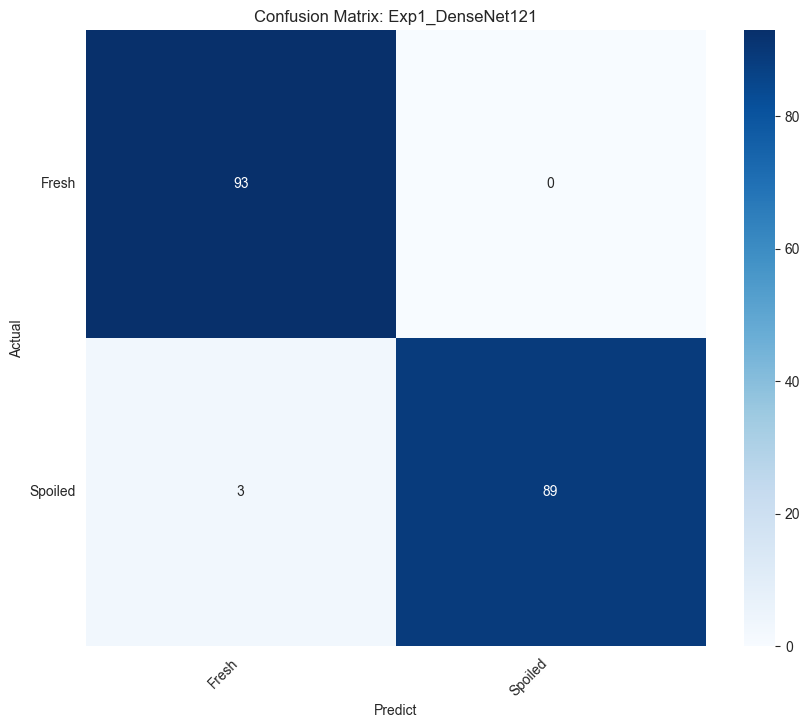

In [11]:
def create_densenet():
    # Load the pre-trained model (without the top/classification head)
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the initial weights (feature extraction)
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),  # Stabilize training
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),          # Prevent aggressive overfitting
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# Run Exp 3
model_3 = create_densenet()
hist_3 = run_experiment(model_3, "Exp3_DenseNet121", epochs=200)
evaluate_and_plot(model_3, hist_3, "Exp3_DenseNet121")

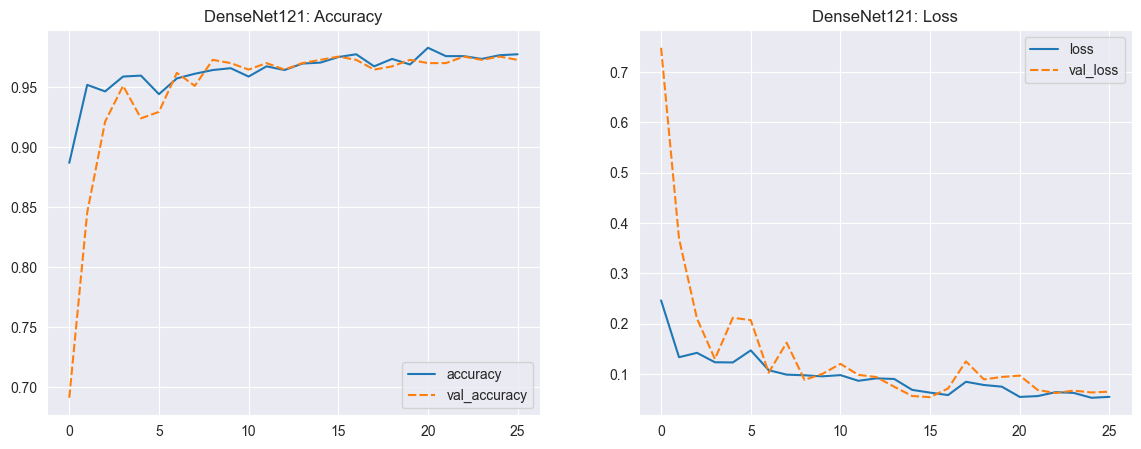


--- Evaluasi pada Data Test: DenseNet121 ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step
              precision    recall  f1-score   support

       Fresh       0.97      1.00      0.98        93
     Spoiled       1.00      0.97      0.98        92

    accuracy                           0.98       185
   macro avg       0.98      0.98      0.98       185
weighted avg       0.98      0.98      0.98       185



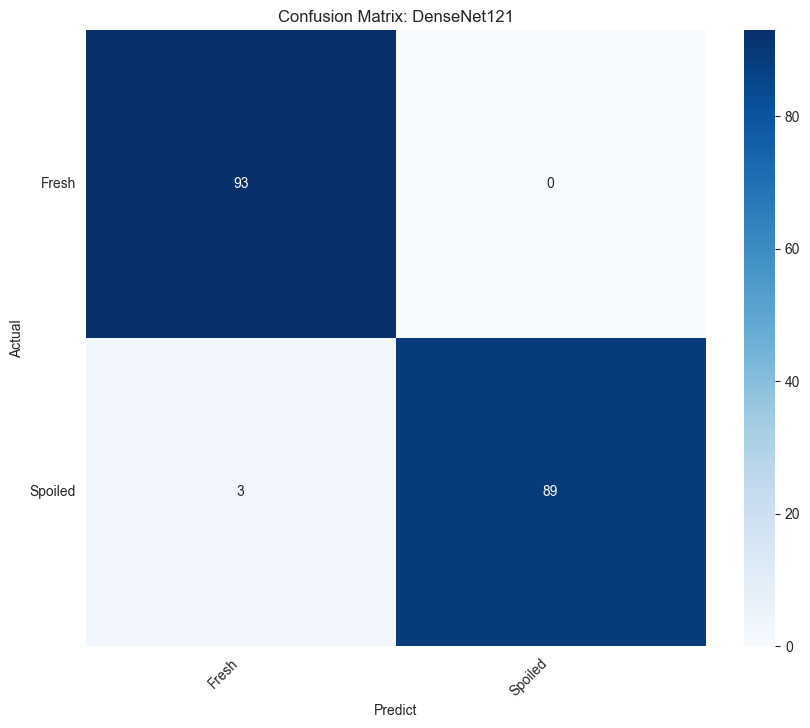

In [12]:
evaluate_and_plot(model_3, hist_3, "DenseNet121")